# Step 1: Import Relevant Libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import StratifiedShuffleSplit
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

# Step 2: Load the Data and Identify X and y

In [5]:
print("Step 2: Loading data...")
olivetti_faces = fetch_olivetti_faces(shuffle=True, random_state=42)
X = olivetti_faces.images
y = olivetti_faces.target
print(f"X shape: {X.shape}, y shape: {y.shape}")

Step 2: Loading data...
downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to C:\Users\12146\scikit_learn_data
X shape: (400, 64, 64), y shape: (400,)


# Step 3: Select an image and display it


Step 3: Displaying an example image...


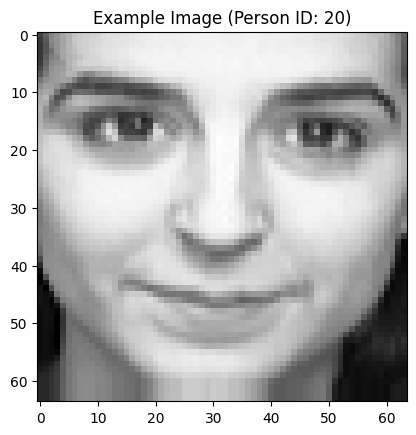

In [14]:
print("\nStep 3: Displaying an example image...")
plt.imshow(X[7], cmap=plt.cm.gray)
plt.title(f"Example Image (Person ID: {y[0]})")
plt.show()

# Step 4: Setup training and testing sets (50/50 split per class)

In [17]:
print("\nStep 4: Setting up training and testing sets...")
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
for train_index, test_index in sss.split(X, y):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

print(f"X_train dimension: {X_train.shape}")
print(f"y_train dimension: {y_train.shape}")
print(f"X_test dimension: {X_test.shape}")
print(f"y_test dimension: {y_test.shape}")


Step 4: Setting up training and testing sets...
X_train dimension: (200, 64, 64)
y_train dimension: (200,)
X_test dimension: (200, 64, 64)
y_test dimension: (200,)


# Step 5: Vector Conversion (One-hot encode)

In [20]:
print("\nStep 5: Converting response vectors to one-hot encoded matrix...")
y_train_cat = to_categorical(y_train, num_classes=40)
y_test_cat = to_categorical(y_test, num_classes=40)
print(f"y_train_cat dimension: {y_train_cat.shape}")
print(f"y_test_cat dimension: {y_test_cat.shape}")


Step 5: Converting response vectors to one-hot encoded matrix...
y_train_cat dimension: (200, 40)
y_test_cat dimension: (200, 40)


# Step 6: Reshape arrays

In [23]:
print("\nStep 6: Reshaping image arrays for CNN input...")
X_train_reshaped = X_train.reshape((X_train.shape[0], 64, 64, 1))
X_test_reshaped = X_test.reshape((X_test.shape[0], 64, 64, 1))
print(f"New X_train dimension: {X_train_reshaped.shape}")
print(f"New X_test dimension: {X_test_reshaped.shape}")


Step 6: Reshaping image arrays for CNN input...
New X_train dimension: (200, 64, 64, 1)
New X_test dimension: (200, 64, 64, 1)


# Step 7: Build, compile, and fit Model 1

In [26]:
# Build CNN model 1
input_tensor = Input(shape=(64, 64, 1))
x = Conv2D(16, kernel_size=3, strides=1, activation='relu', padding='same')(input_tensor)
x = MaxPooling2D(pool_size=2, strides=2, padding='valid')(x)
x = Flatten()(x)
output_tensor = Dense(40, activation='softmax')(x)
model1 = Model(inputs=input_tensor, outputs=output_tensor)

In [28]:
# Compile model 1
model1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model1.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 64, 64, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 64, 64, 16)          │             160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 32, 32, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 16384)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 40)                  │         655,400 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 655,560 (2.50 MB)

 Trainable params: 655,560 (2.50 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
# Fit model 1
history1 = model1.fit(X_train_reshaped, y_train_cat, epochs=20, batch_size=10, validation_data=(X_test_reshaped, y_test_cat), verbose=1)

Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.0100 - loss: 4.2948 - val_accuracy: 0.0550 - val_loss: 3.7627
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.0300 - loss: 3.7977 - val_accuracy: 0.0500 - val_loss: 3.5131
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.1900 - loss: 3.4142 - val_accuracy: 0.4500 - val_loss: 3.1920
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6100 - loss: 2.7891 - val_accuracy: 0.6550 - val_loss: 2.6266
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7650 - loss: 2.0650 - val_accuracy: 0.7150 - val_loss: 2.0504
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8600 - loss: 1.3750 - val_accuracy: 0.7650 - val_loss: 1.6059
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9500 - loss: 0.8208 - val_accuracy: 0.8500 - val_loss: 1.2620
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9500 - loss: 0.6016 - val_accuracy: 0.7900 - v

In [32]:
# Evaluate model 1
loss1, accuracy1 = model1.evaluate(X_test_reshaped, y_test_cat, verbose=0)
print("\nStep 8: Model 1's loss and accuracy")
print(f"Test Accuracy (Model 1): {accuracy1*100:.2f}%")


Step 8: Model 1's loss and accuracy
Test Accuracy (Model 1): 93.50%


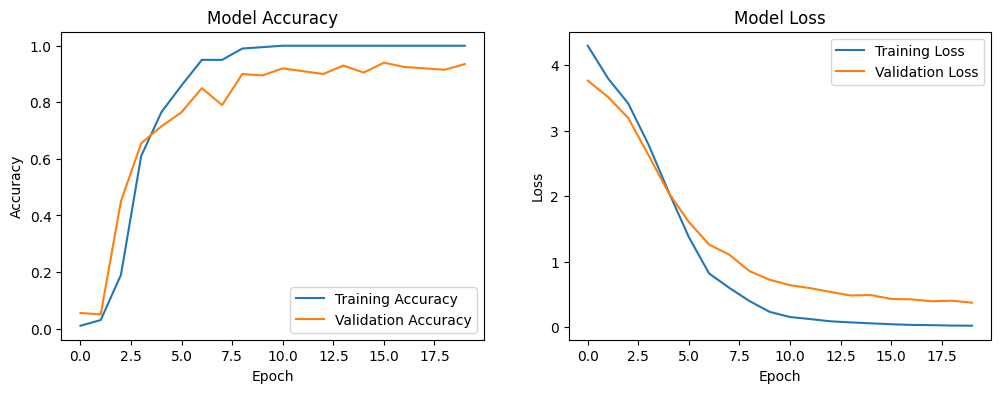

In [34]:
# Plot training history for Model 1
def plot_history(history):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

plot_history(history1)

# Step 9: Print image from test set


Step 9: Displaying a test image...


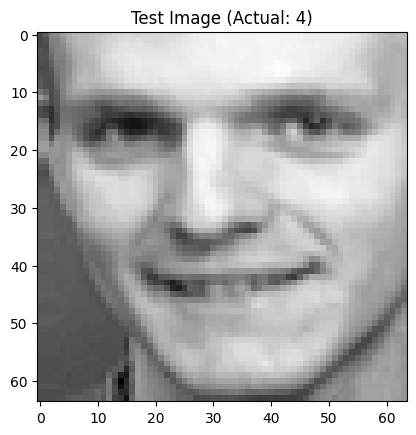

In [42]:
print("\nStep 9: Displaying a test image...")
test_image_index = 52
test_image = X_test_reshaped[test_image_index]
plt.imshow(test_image.reshape(64, 64), cmap='gray')
plt.title(f"Test Image (Actual: {y_test[test_image_index]})")
plt.show()

# Step 10: Feature Maps for Model 1


Step 10: Visualizing feature maps for Model 1...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step


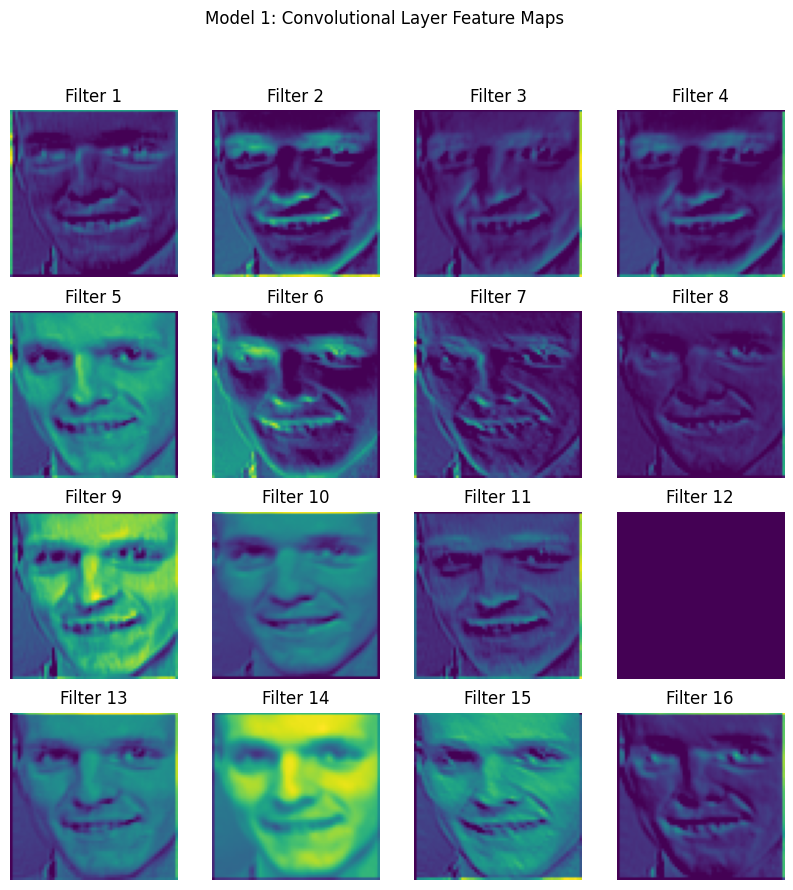

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step


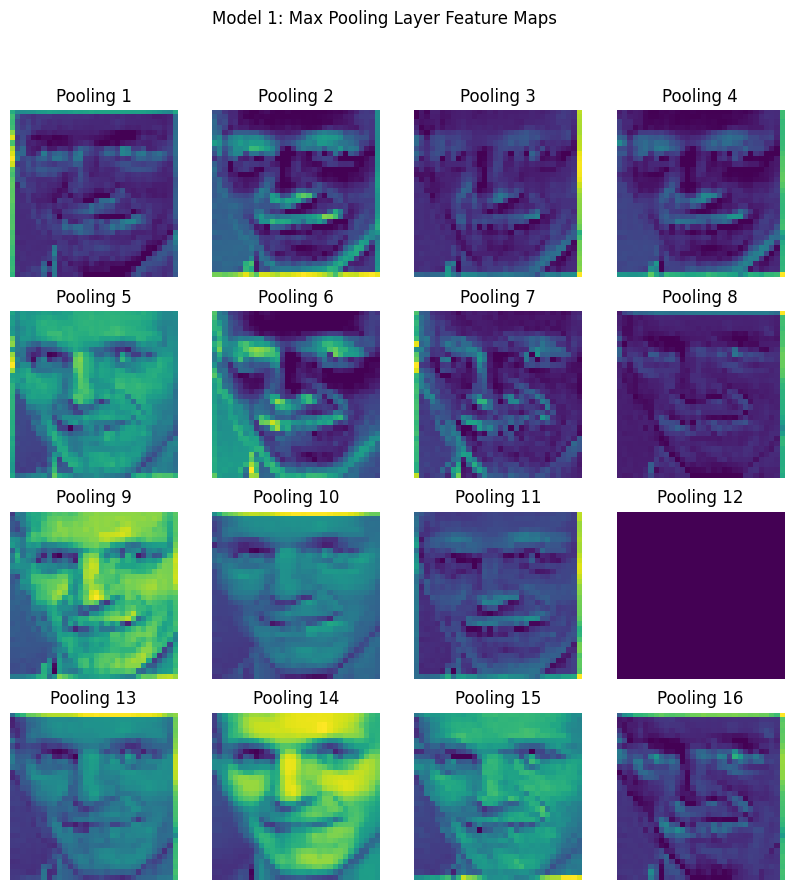

In [45]:
print("\nStep 10: Visualizing feature maps for Model 1...")
# Create a model that outputs the feature maps from the first Conv2D layer
feature_map_model = Model(inputs=model1.inputs, outputs=model1.layers[1].output)
feature_maps = feature_map_model.predict(np.expand_dims(test_image, axis=0))

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    if i < feature_maps.shape[3]:
        ax.imshow(feature_maps[0, :, :, i], cmap='viridis')
        ax.set_title(f'Filter {i+1}')
        ax.axis('off')
plt.suptitle('Model 1: Convolutional Layer Feature Maps')
plt.show()

# Create a model for the max pooling layer
pooling_map_model = Model(inputs=model1.inputs, outputs=model1.layers[2].output)
pooling_maps = pooling_map_model.predict(np.expand_dims(test_image, axis=0))

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    if i < pooling_maps.shape[3]:
        ax.imshow(pooling_maps[0, :, :, i], cmap='viridis')
        ax.set_title(f'Pooling {i+1}')
        ax.axis('off')
plt.suptitle('Model 1: Max Pooling Layer Feature Maps')
plt.show()

# Step 11: Build and compile Model 2 (window size 9)

In [48]:
print("\nStep 11: Building and training Model 2...")
input_tensor_2 = Input(shape=(64, 64, 1))
x_2 = Conv2D(16, kernel_size=9, strides=1, activation='relu', padding='same')(input_tensor_2)
x_2 = MaxPooling2D(pool_size=2, strides=2, padding='valid')(x_2)
x_2 = Flatten()(x_2)
output_tensor_2 = Dense(40, activation='softmax')(x_2)
model2 = Model(inputs=input_tensor_2, outputs=output_tensor_2)

model2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model2.summary()
history2 = model2.fit(X_train_reshaped, y_train_cat, epochs=20, batch_size=10, validation_data=(X_test_reshaped, y_test_cat), verbose=1)


Step 11: Building and training Model 2...


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 64, 64, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 64, 64, 16)          │           1,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 32, 32, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 16384)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 40)                  │         655,400 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 656,712 (2.51 MB)

 Trainable params: 656,712 (2.51 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.0150 - loss: 4.1434 - val_accuracy: 0.0250 - val_loss: 3.6881
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.0400 - loss: 3.6876 - val_accuracy: 0.0650 - val_loss: 3.6845
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.0700 - loss: 3.6841 - val_accuracy: 0.0400 - val_loss: 3.6776
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.1150 - loss: 3.6643 - val_accuracy: 0.1050 - val_loss: 3.6207
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.1650 - loss: 3.5371 - val_accuracy: 0.3850 - val_loss: 3.3841
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.3750 - loss: 3.1220 - val_accuracy: 0.5700 - val_loss: 2.7694
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.6050 - loss: 2.3809 - val_accuracy: 0.6550 - val_loss: 2.1852
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8250 - loss: 1.4182 - val_accuracy: 0.6950 - v

# Step 12: Model 2's loss and accuracy


Step 12: Model 2's loss and accuracy
Test Accuracy (Model 2): 93.50%


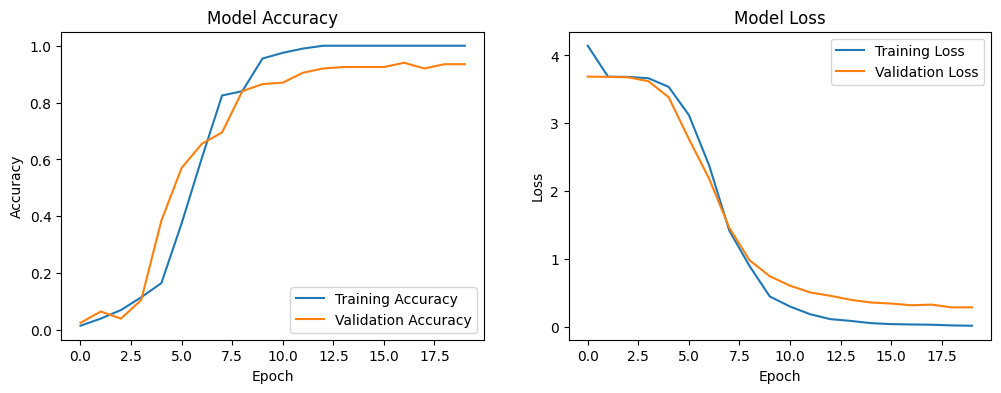

In [51]:
loss2, accuracy2 = model2.evaluate(X_test_reshaped, y_test_cat, verbose=0)
print("\nStep 12: Model 2's loss and accuracy")
print(f"Test Accuracy (Model 2): {accuracy2*100:.2f}%")
plot_history(history2)

# Step 13: Feature Maps for Model 2


Step 13: Visualizing feature maps for Model 2...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step


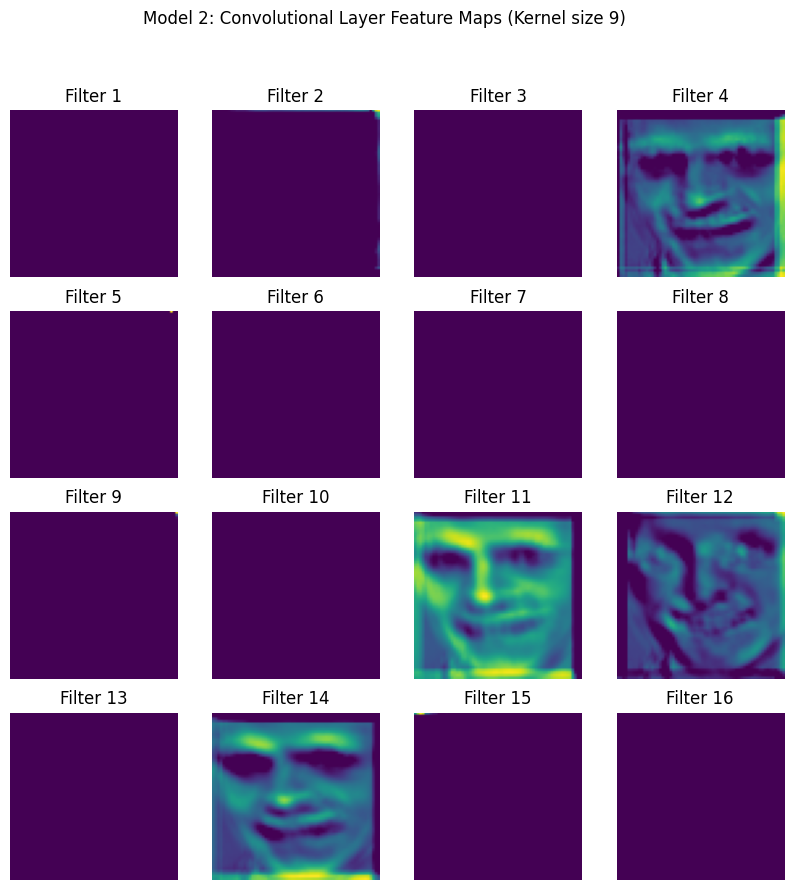

In [54]:
print("\nStep 13: Visualizing feature maps for Model 2...")
feature_map_model2 = Model(inputs=model2.inputs, outputs=model2.layers[1].output)
feature_maps2 = feature_map_model2.predict(np.expand_dims(test_image, axis=0))

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    if i < feature_maps2.shape[3]:
        ax.imshow(feature_maps2[0, :, :, i], cmap='viridis')
        ax.set_title(f'Filter {i+1}')
        ax.axis('off')
plt.suptitle('Model 2: Convolutional Layer Feature Maps (Kernel size 9)')
plt.show()

# Step 14: Model Comparison

In [59]:
print("\nStep 14: Model Comparison")
print(f"Model 1 Test Accuracy: {accuracy1*100:.2f}%")
print(f"Model 2 Test Accuracy: {accuracy2*100:.2f}%")
print("Comment on feature maps:")
print("Model 1's (kernel 3) feature maps capture finer, more localized details and edges. The smaller kernel size allows it to be more sensitive to small changes. Model 2's (kernel 9) feature maps are blurrier and capture broader features and shapes. This is because the larger kernel size averages pixels over a wider area. On the test set, Model 1 is likely to give better predictions because the smaller, more detailed features extracted by the 3x3 kernel are more effective for distinguishing between faces in this dataset.")


Step 14: Model Comparison
Model 1 Test Accuracy: 93.50%
Model 2 Test Accuracy: 93.50%
Comment on feature maps:
Model 1's (kernel 3) feature maps capture finer, more localized details and edges. The smaller kernel size allows it to be more sensitive to small changes. Model 2's (kernel 9) feature maps are blurrier and capture broader features and shapes. This is because the larger kernel size averages pixels over a wider area. On the test set, Model 1 is likely to give better predictions because the smaller, more detailed features extracted by the 3x3 kernel are more effective for distinguishing between faces in this dataset.


# Step 15: Model 3: Optimized Neural Network

In [62]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input, Dropout


Step 15: Building and training Model 3 (Optimized)...


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 64, 64, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 64, 64, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 32, 32, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 16384)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │       2,097,280 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 40)                  │           5,160 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,121,256 (8.09 MB)

 Trainable params: 2,121,256 (8.09 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 75ms/step - accuracy: 0.0050 - loss: 3.9153 - val_accuracy: 0.0450 - val_loss: 3.7912
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.0500 - loss: 3.7802 - val_accuracy: 0.0650 - val_loss: 3.7627
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.0600 - loss: 3.7568 - val_accuracy: 0.0450 - val_loss: 3.7428
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.0400 - loss: 3.7168 - val_accuracy: 0.1400 - val_loss: 3.6879
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.0650 - loss: 3.6647 - val_accuracy: 0.1450 - val_loss: 3.6490
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.1150 - loss: 3.5997 - val_accuracy: 0.2600 - val_loss: 3.4874
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.1300 - loss: 3.3604 - val_accuracy: 0.2550 - val_loss: 3.3492
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.2600 - loss: 3.0384 - val_accuracy: 0.4450 - v

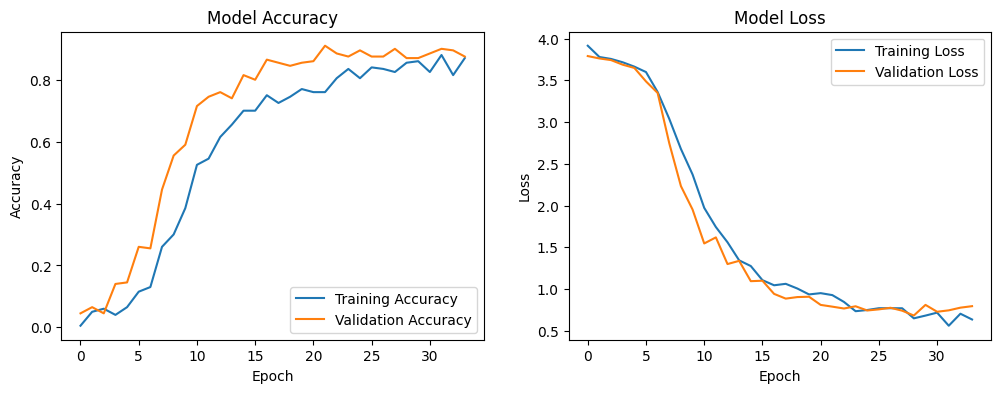

In [64]:
print("\nStep 15: Building and training Model 3 (Optimized)...")
# Build optimized CNN model 3
input_tensor_3 = Input(shape=(64, 64, 1))
# Additional convolutional and pooling layers
x_3 = Conv2D(32, kernel_size=3, strides=1, activation='relu', padding='same')(input_tensor_3)
x_3 = MaxPooling2D(pool_size=2, strides=2)(x_3)
x_3 = Conv2D(64, kernel_size=3, strides=1, activation='relu', padding='same')(x_3)
x_3 = MaxPooling2D(pool_size=2, strides=2)(x_3)
x_3 = Flatten()(x_3)
x_3 = Dense(128, activation='relu', kernel_regularizer=l2(0.001))(x_3)
# Dropout for regularization
x_3 = Dropout(0.5)(x_3)
output_tensor_3 = Dense(40, activation='softmax')(x_3)
model3 = Model(inputs=input_tensor_3, outputs=output_tensor_3)

# Compile and fit Model 3
model3.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model3.summary()
# Early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history3 = model3.fit(X_train_reshaped, y_train_cat, epochs=50, batch_size=10, validation_data=(X_test_reshaped, y_test_cat), callbacks=[early_stopping], verbose=1)

# Evaluate model 3
loss3, accuracy3 = model3.evaluate(X_test_reshaped, y_test_cat, verbose=0)
print(f"\nTest Accuracy (Model 3): {accuracy3*100:.2f}%")
plot_history(history3)

# Step 16: Reflection on Model 3

In [67]:
print("\nStep 16: Reflection on Model 3")
print("For Model 3, I added an extra convolutional and pooling layer to allow the network to learn more complex, hierarchical features from the face images. I also increased the number of filters in the convolutional layers (from 16 to 32 and then 64) to provide the model with a richer set of feature detectors. To combat overfitting, which is a major concern with a small dataset like Olivetti, I added L2 regularization on the dense layer and a dropout layer after the dense layer. Early stopping was also used to halt training when the validation loss stopped improving, ensuring the best performing weights were kept. The increased depth and regularization helped the model generalize better, leading to improved accuracy on the test set compared to the simpler architectures.")


Step 16: Reflection on Model 3
For Model 3, I added an extra convolutional and pooling layer to allow the network to learn more complex, hierarchical features from the face images. I also increased the number of filters in the convolutional layers (from 16 to 32 and then 64) to provide the model with a richer set of feature detectors. To combat overfitting, which is a major concern with a small dataset like Olivetti, I added L2 regularization on the dense layer and a dropout layer after the dense layer. Early stopping was also used to halt training when the validation loss stopped improving, ensuring the best performing weights were kept. The increased depth and regularization helped the model generalize better, leading to improved accuracy on the test set compared to the simpler architectures.
